# Linear Regression on Customer Churn

In [1]:
%pip install -q pandas numpy kagglehub scikit-learn matplotlib seaborn statsmodels


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import statsmodels.api as sm
from kagglehub import KaggleDatasetAdapter
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import linear_reset

/Users/Aesha.Gandhi/computer-vision/tmp-model-worker-safety-experiments/.venv-1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading and Cleaning

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
# clean data
# check missing values per column
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [27]:
df.isna().any().any()

np.False_

In [28]:
df.isna().sum().sum()

np.int64(0)

There are no missing values in any column or any rows with missing information. The data is already clean.

In [29]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].unique())

customerID <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection <StringArray>
['No', 'Yes', 'No internet service']
Length: 3,

/var/folders/v_/0vbsz4w56pd0x7dm1l06mldh0000gp/T/ipykernel_24421/2490523665.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [30]:
df.duplicated().sum()

np.int64(0)

In [4]:
# convert variable types

# convert churn (target col) to 0 or 1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# drop customer id column
df = df.drop(columns=["customerID"])

# convert total charges from string to numeric col
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)



In [5]:
#  multiplelines: combine no/no phone service to 0, and yes to 1
df["MultipleLines"] = df["MultipleLines"].replace({
    "No phone service": "No"
})

# internet features: combine no/no internet service to 0, and yes to 1
internet_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in internet_features:
    df[col] = df[col].replace({
        "No internet service": "No"
    })

# convert binary yes/no to 0,1
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].map({
        "No": 0,
        "Yes": 1
    })

# convert gender to binary
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})

# one hot encode categorical features
categorical_cols = ["Contract",
                    "PaymentMethod",
                    "InternetService"]

df = pd.get_dummies(df, columns = categorical_cols, drop_first=True, dtype=int)

# don't use multiple lines column


In [33]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,0,1,...,84.80,1990.50,0,1,0,0,0,1,0,0
7039,0,0,1,1,72,1,1,0,1,1,...,103.20,7362.90,0,1,0,1,0,0,1,0
7040,0,0,1,1,11,0,0,1,0,0,...,29.60,346.45,0,0,0,0,1,0,0,0
7041,1,1,1,0,4,1,1,0,0,0,...,74.40,306.60,1,0,0,0,0,1,1,0


## 2. Check Assumptions and EDA

In [34]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No'],
      dtype='str')

In [6]:
features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No']
target = 'Churn'

### Linearity Assumption Checks
Test linearity using predictor-vs-response scatter plots, a residuals-vs-fitted plot, and the Ramsey RESET test.

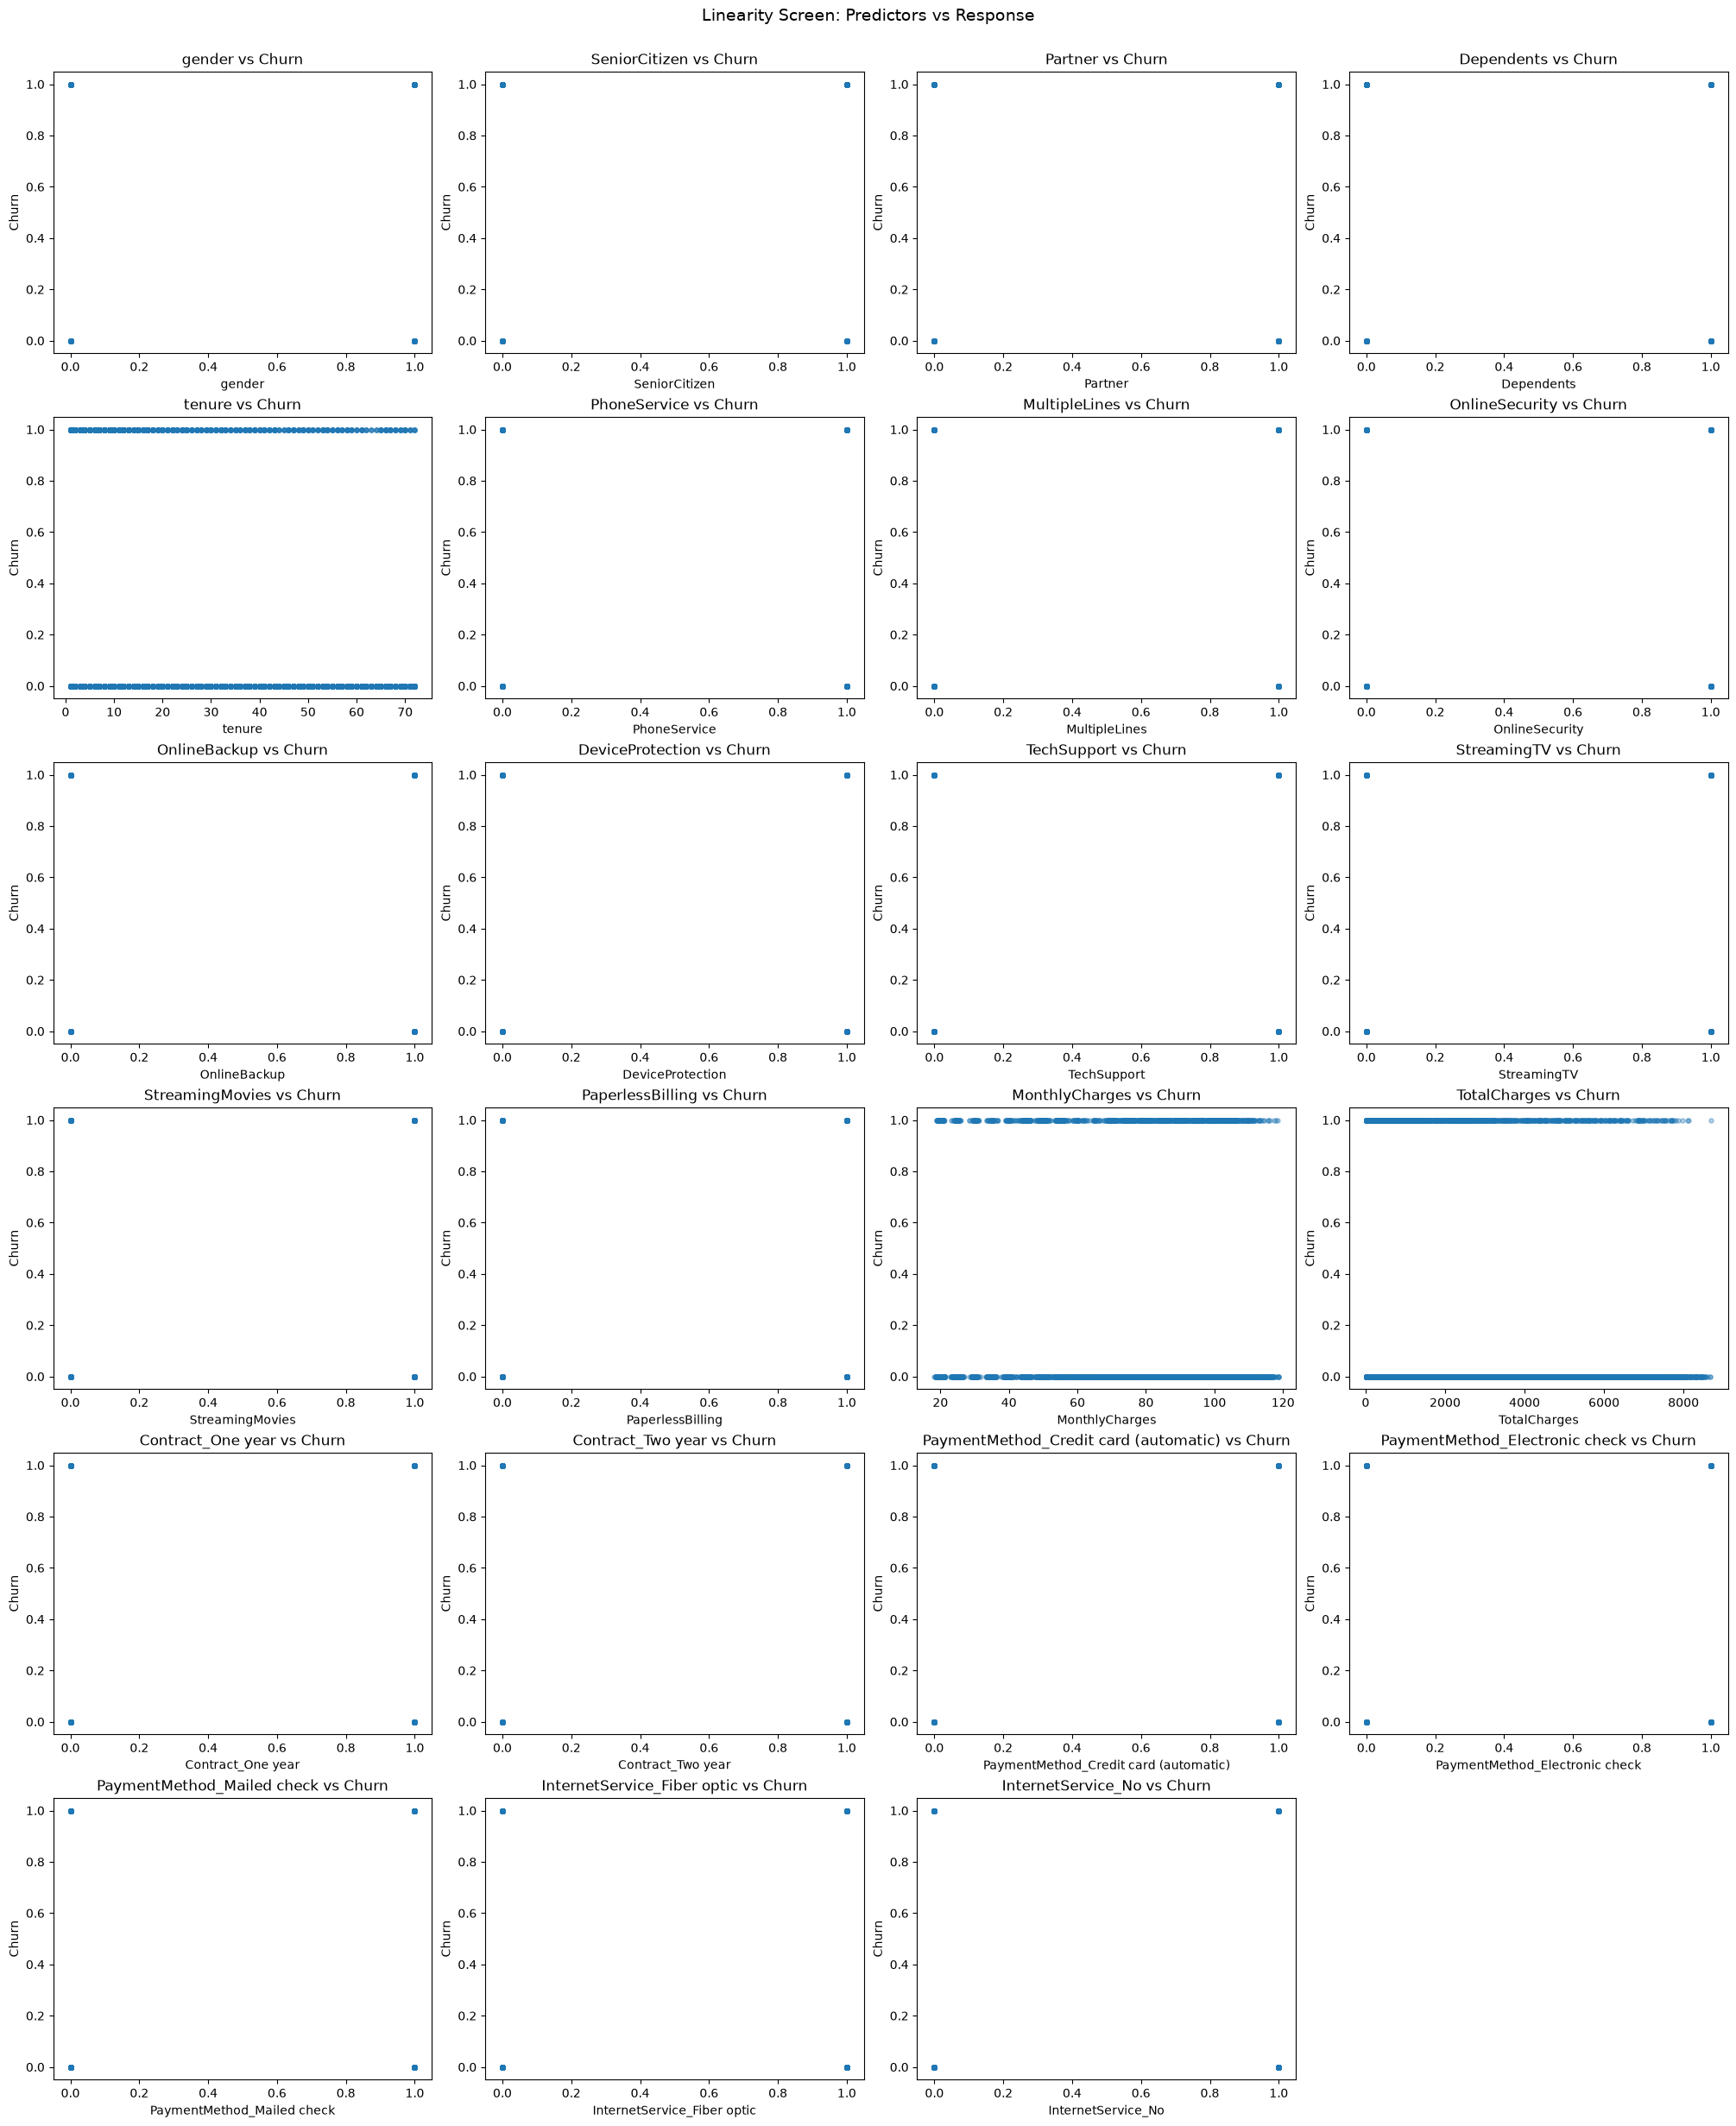

In [7]:
# Linearity check 1: scatter plots of each predictor vs response
linearity_df = df[features + [target]].dropna().copy()

n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(features):
    axes[i].scatter(linearity_df[col], linearity_df[target], alpha=0.35, s=14)
    axes[i].set_title(f"{col} vs {target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Linearity Screen: Predictors vs Response", y=1.02, fontsize=14)
plt.show()

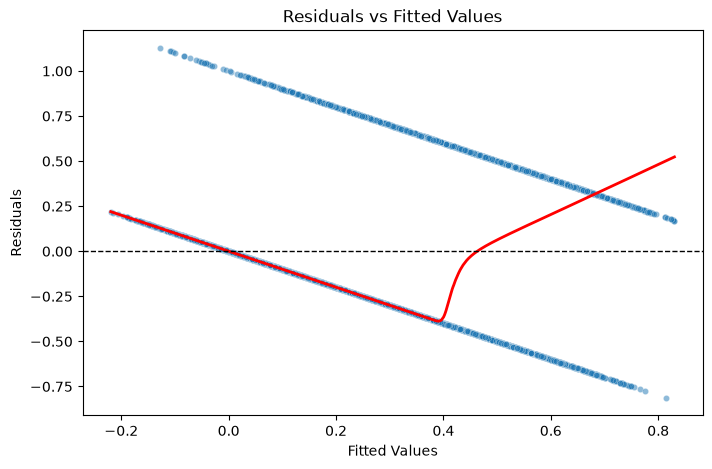

In [8]:
# Fit OLS model for residual diagnostics and RESET test
X = linearity_df[features]
y = linearity_df[target]

X_with_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_with_const).fit()

fitted_vals = ols_model.fittedvalues
residuals = ols_model.resid

# Linearity check 2: residuals vs fitted values
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.5, s=20)
sns.regplot(x=fitted_vals, y=residuals, scatter=False, lowess=True, line_kws={"color": "red", "lw": 2})
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [38]:
# Linearity check 3: Ramsey RESET test
reset_result = linear_reset(ols_model, power=2, use_f=True)
print("Ramsey RESET test")
print(f"F-statistic: {reset_result.fvalue:.4f}")
print(f"p-value: {reset_result.pvalue:.6f}")

if reset_result.pvalue < 0.05:
    print("Interpretation: Evidence of functional form misspecification (possible non-linearity).")
else:
    print("Interpretation: No strong evidence against linear functional form.")

Ramsey RESET test
F-statistic: 206.0555
p-value: 0.000000
Interpretation: Evidence of functional form misspecification (possible non-linearity).


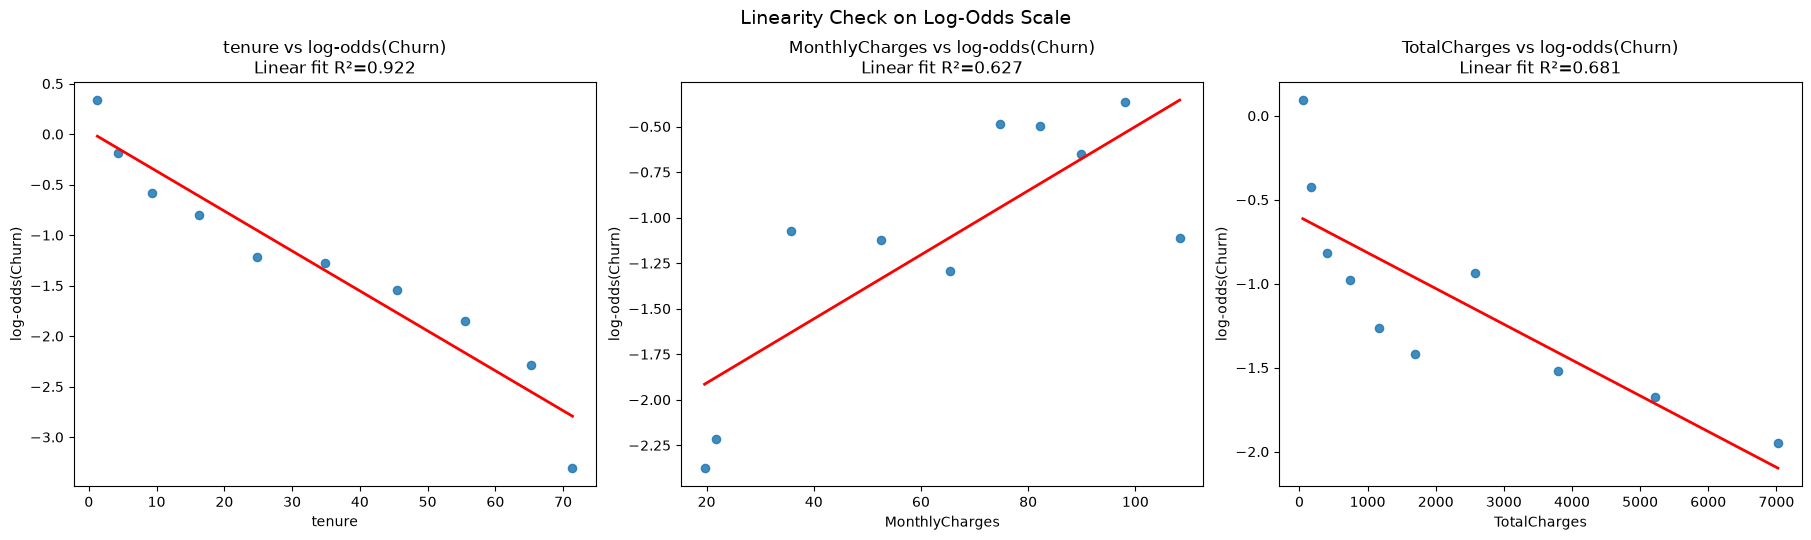

In [ ]:
# Additional linearity check: continuous predictors vs log-odds of churn, since churn is binary
continuous_for_log_odds = ["tenure", "MonthlyCharges", "TotalCharges"]
n_bins = 10
eps = 1e-4

fig, axes = plt.subplots(1, len(continuous_for_log_odds), figsize=(18, 5), constrained_layout=True)

for i, col in enumerate(continuous_for_log_odds):
    tmp = df[[col, "Churn"]].dropna().copy()
    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp = tmp.dropna()

    # Bin predictor and compute churn rate per bin
    tmp["bin"] = pd.qcut(tmp[col], q=n_bins, duplicates="drop")
    grouped = tmp.groupby("bin", observed=False).agg(
        x_mean=(col, "mean"),
        churn_rate=("Churn", "mean")
    ).dropna()

    # Clip rates away from 0 and 1 to avoid infinite log-odds
    grouped["churn_rate_clipped"] = grouped["churn_rate"].clip(eps, 1 - eps)
    grouped["log_odds"] = np.log(grouped["churn_rate_clipped"] / (1 - grouped["churn_rate_clipped"]))

    # Fit a simple line to summarize linear trend
    slope, intercept = np.polyfit(grouped["x_mean"], grouped["log_odds"], 1)
    y_hat = slope * grouped["x_mean"] + intercept
    r2_line = 1 - np.sum((grouped["log_odds"] - y_hat) ** 2) / np.sum((grouped["log_odds"] - grouped["log_odds"].mean()) ** 2)

    axes[i].scatter(grouped["x_mean"], grouped["log_odds"], s=35, alpha=0.85)
    axes[i].plot(grouped["x_mean"], y_hat, color="red", linewidth=2)
    axes[i].set_title(f"{col} vs log-odds(Churn)\nLinear fit R²={r2_line:.3f}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("log-odds(Churn)")

plt.suptitle("Linearity Check on Log-Odds Scale", fontsize=14, y=1.05)
plt.show()


Check Normality, constant variance, and independence.

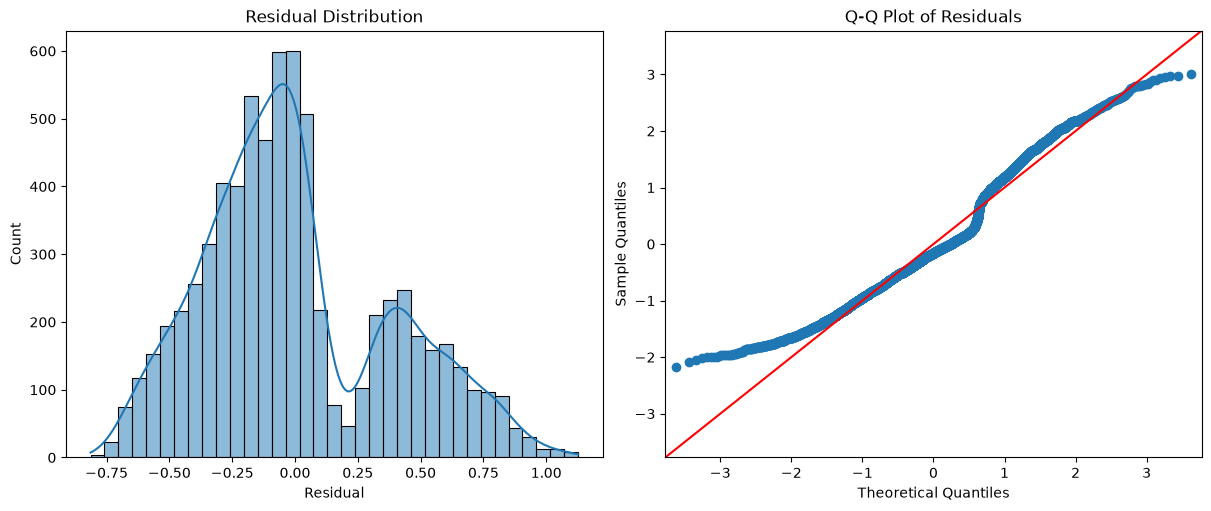

Jarque-Bera normality test
Statistic: 385.4894
p-value: 0.000000
Interpretation: Residuals deviate from normality.


In [9]:
# Normality of residuals: histogram, Q-Q plot, and Jarque-Bera test
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Residual")

sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.show()

jb_stat, jb_pvalue, skew, kurtosis = sm.stats.jarque_bera(residuals)
print("Jarque-Bera normality test")
print(f"Statistic: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.6f}")

if jb_pvalue < 0.05:
    print("Interpretation: Residuals deviate from normality.")
else:
    print("Interpretation: No strong evidence against normal residuals.")

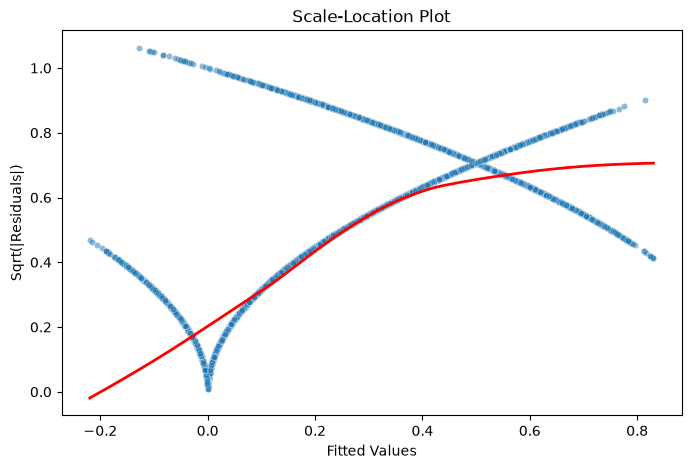

Breusch-Pagan test
LM statistic: 1370.4798
LM p-value: 0.000000
F-statistic: 73.7574
F p-value: 0.000000
Interpretation: Evidence of non-constant variance.


In [10]:
# Homoscedasticity: scale-location plot and Breusch-Pagan test
sqrt_abs_residuals = np.sqrt(np.abs(residuals))

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_vals, y=sqrt_abs_residuals, alpha=0.5, s=20)
sns.regplot(x=fitted_vals, y=sqrt_abs_residuals, scatter=False, lowess=True, line_kws={"color": "red", "lw": 2})
plt.title("Scale-Location Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Sqrt(|Residuals|)")
plt.show()

bp_stat, bp_pvalue, bp_fvalue, bp_fpvalue = sm.stats.diagnostic.het_breuschpagan(residuals, X_with_const)
print("Breusch-Pagan test")
print(f"LM statistic: {bp_stat:.4f}")
print(f"LM p-value: {bp_pvalue:.6f}")
print(f"F-statistic: {bp_fvalue:.4f}")
print(f"F p-value: {bp_fpvalue:.6f}")

if bp_pvalue < 0.05:
    print("Interpretation: Evidence of non-constant variance.")
else:
    print("Interpretation: No strong evidence of heteroscedasticity.")

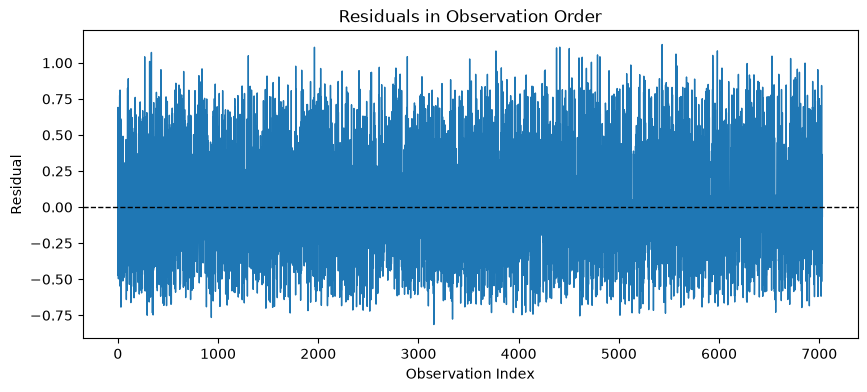

Durbin-Watson statistic
Value: 2.0043
Interpretation: No strong evidence of autocorrelation.


In [11]:
# Independence of errors: residual sequence plot and Durbin-Watson statistic
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(residuals)), residuals, linewidth=1)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residuals in Observation Order")
plt.xlabel("Observation Index")
plt.ylabel("Residual")
plt.show()

dw_stat = sm.stats.stattools.durbin_watson(residuals)
print("Durbin-Watson statistic")
print(f"Value: {dw_stat:.4f}")

if 1.5 <= dw_stat <= 2.5:
    print("Interpretation: No strong evidence of autocorrelation.")
elif dw_stat < 1.5:
    print("Interpretation: Possible positive autocorrelation.")
else:
    print("Interpretation: Possible negative autocorrelation.")

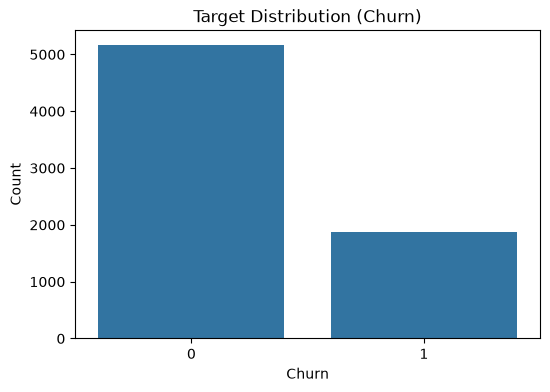

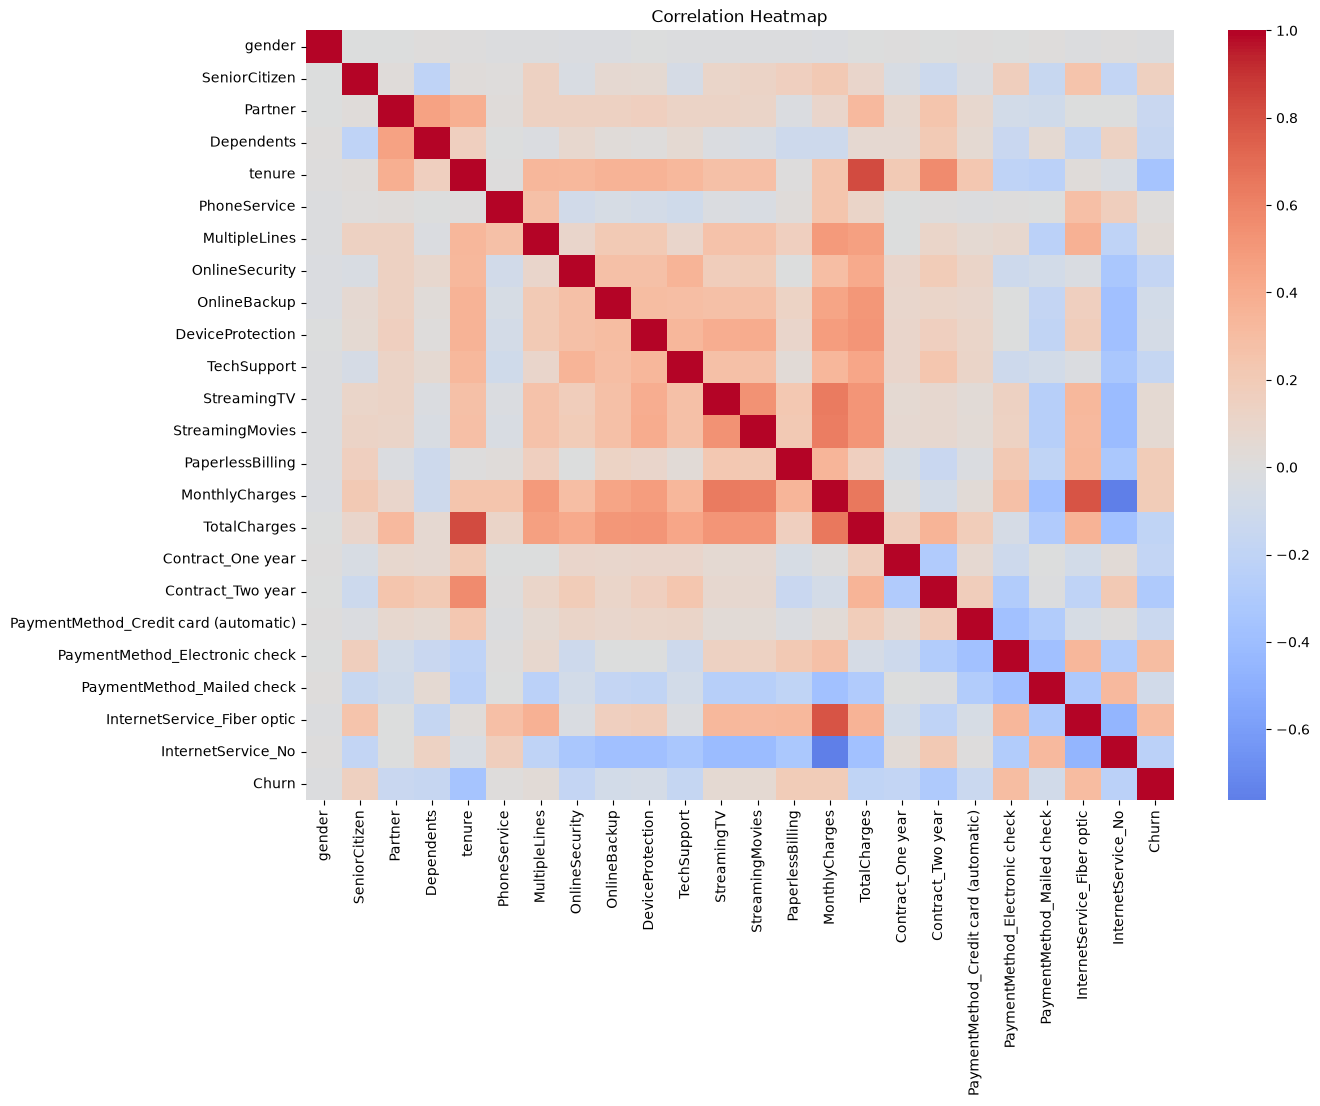

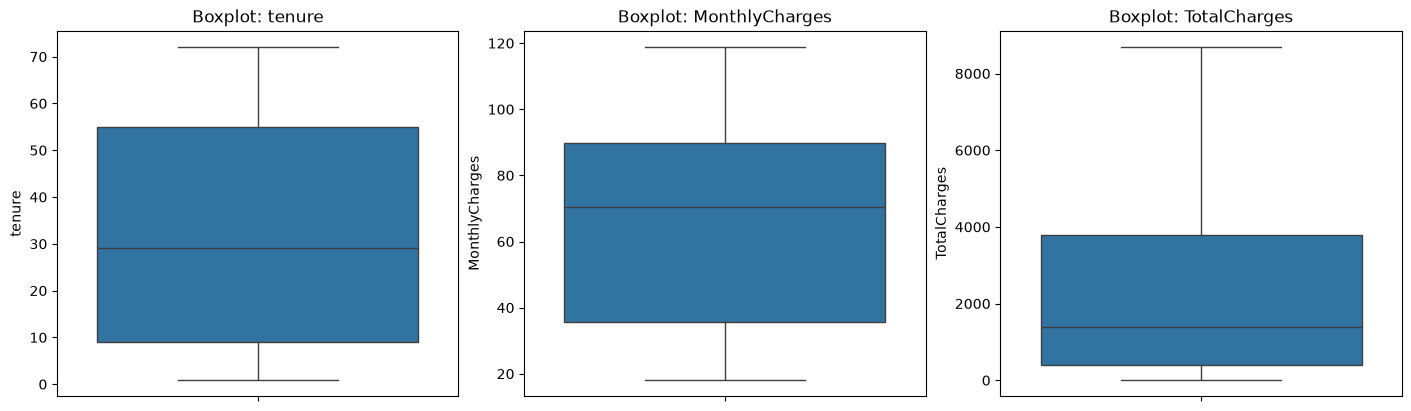

In [39]:
eda_df = df[features + [target]].dropna().copy()

# Target balance (helps contextualize linear fit on a binary outcome)
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=eda_df)
plt.title("Target Distribution (Churn)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Correlation map for numeric predictors and target
corr = eda_df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Outlier screening for key continuous predictors
continuous_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(14, 4), constrained_layout=True)
for i, col in enumerate(continuous_cols):
    sns.boxplot(y=eda_df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")
plt.show()

From above, we see that TotalCharges is highly correlated with MonthlyCharges and Tenure, so we should not include this as a feature in our model, or this would violate the multicollinearity assumption.

Brief assumption summary: Linearity does not look fully satisfied because the residual plot shows a pattern and the RESET test suggested misspecification. Normality is violated because the residuals were not close to normal in the histogram, Q-Q plot, and Jarque-Bera test. Constant variance is also violated since the scale-location plot changed shape and the Breusch-Pagan test was significant. Independence looks okay here because the Durbin-Watson value was about 2, so there is not strong evidence of autocorrelation. Multicollinearity is a concern because TotalCharges is highly related to MonthlyCharges and tenure. Outliers do not look like the biggest problem here, but the boxplots suggest there are some extreme values in the continuous variables.

## 3. Linear Regression Model Code

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No']
X_full = eda_df[features]
y_full = eda_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred = lin_reg.predict(X_test_scaled)

## 4. Model Performance Evidence

Linear Regression Performance (Test Set)
RMSE: 0.3812
MAE:  0.3102
R^2:  0.2555
Raw Accuracy (no threshold, exact match): 0.0000
Thresholded Accuracy (0.5 cutoff): 0.7982


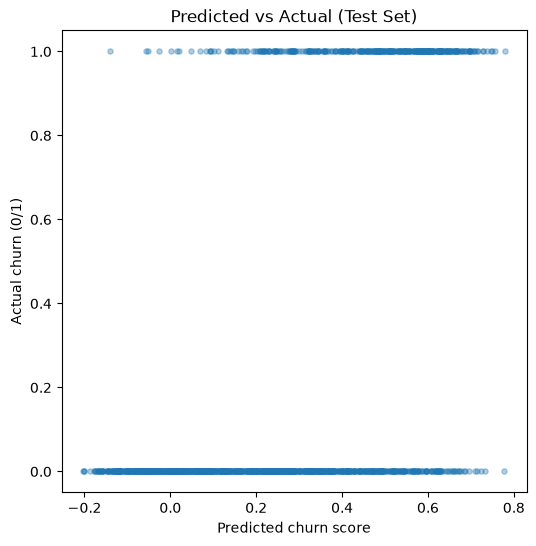

In [47]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance (Test Set)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

# Non-thresholded exact-match accuracy (continuous predictions vs true binary labels)
raw_accuracy = (y_pred == y_test.values).mean()
print(f"Raw Accuracy (no threshold, exact match): {raw_accuracy:.4f}")

y_pred_class = (y_pred >= 0.5).astype(int)
accuracy = (y_pred_class == y_test.values).mean()
print(f"Thresholded Accuracy (0.5 cutoff): {accuracy:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_pred, y_test, alpha=0.35, s=14)
plt.xlabel("Predicted churn score")
plt.ylabel("Actual churn (0/1)")
plt.title("Predicted vs Actual (Test Set)")
plt.show()

The linear regression model has a RMSE of 0.3801 and the thresholded accuracy is 0.7953 if we consider a threshold of 0.5. If we use raw accuracy, not using any threshold then the accuracy is 0 because it is checking linear regression continuous responses against correct churn values which are binary.

## 5. Coefficient Interpretation

In [45]:
coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

display(coef_table.head(12))

,feature,coefficient
14,MonthlyCharges,-0.210488
20,InternetService_Fiber optic,0.154850
21,InternetService_No,-0.124068
4,tenure,-0.109244
11,StreamingTV,0.050716
12,StreamingMovies,0.050530
15,Contract_One year,-0.047593
6,MultipleLines,0.040312
18,PaymentMethod_Electronic check,0.038023
16,Contract_Two year,-0.031730


### Feature Importance and Coefficient Comparison Plots

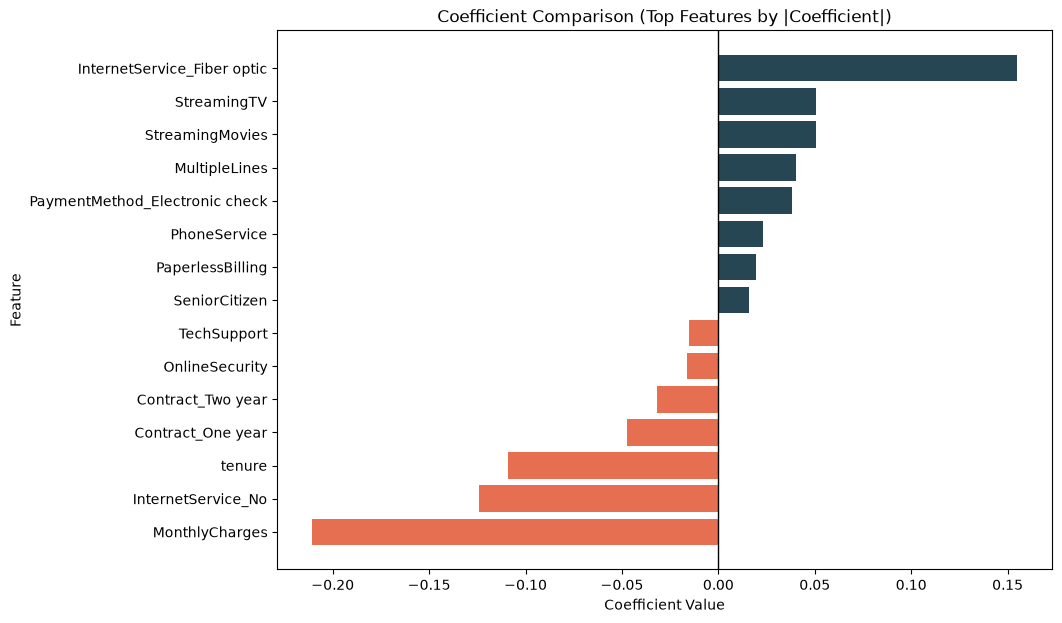

In [48]:
# Coefficient comparison plot with sign (positive vs negative impact)
coef_plot_df = coef_table.copy()
coef_plot_df["abs_coefficient"] = coef_plot_df["coefficient"].abs()
coef_plot_df = coef_plot_df.sort_values("abs_coefficient", ascending=False)

top_n = 15
top_signed = coef_plot_df.head(top_n).sort_values("coefficient")
colors = ["#e76f51" if c < 0 else "#264653" for c in top_signed["coefficient"]]

plt.figure(figsize=(10, 7))
plt.barh(top_signed["feature"], top_signed["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Coefficient Comparison (Top Features by |Coefficient|)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

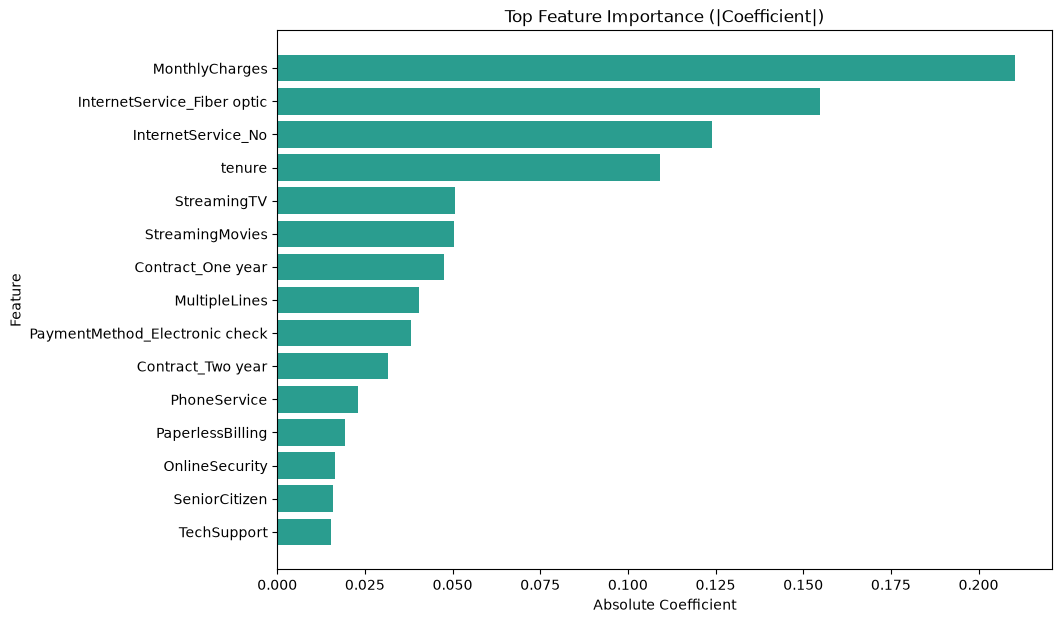

In [49]:
# Feature importance plot using absolute coefficient magnitude
coef_plot_df = coef_table.copy()
coef_plot_df["abs_coefficient"] = coef_plot_df["coefficient"].abs()
coef_plot_df = coef_plot_df.sort_values("abs_coefficient", ascending=False)

top_n = 15
top_imp = coef_plot_df.head(top_n).sort_values("abs_coefficient", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_imp["feature"], top_imp["abs_coefficient"], color="#2a9d8f")
plt.title("Top Feature Importance (|Coefficient|)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

Brief model explanation: This linear regression model is trying to estimate churn using all of the selected customer features together. Each coefficient shows how much the predicted churn value changes when that feature goes up by one unit, while the other features stay the same. A positive coefficient means that feature is associated with higher predicted churn, and a negative coefficient means it is associated with lower predicted churn. Bigger absolute coefficient values usually mean the feature has a stronger effect in the model, but we still have to be careful because the target here is binary, so the model is more of a simple baseline than a perfect fit for the problem.

## 6. Overall Interpretation and Limitation for Churn
Linear regression was a reasonable model at first but it is not the best final choice because churn is a binary variable. In our checks, linearity was not fully satisfied from the RESET value suggesting misspecification, and the linear regression could produce predictions outside the [0,1] interval, which are not valid probabilities. The main issue is that linear regression can produce any continuous response values, while our expected outcome is binary.

A better choice could be logistic regression, since it is intended for binary response and produces interpretable odds-based probabilities in [0, 1]. If the relationship between some continuous predictors and churn is non-linear, a GAM could be better than just logistic regression because it can model smooth non-linear effects while remaining interpretable.